# Logistic Regression: Early-Warning Model (Day 30)

This notebook trains and evaluates a Logistic Regression model using the engineered OULAD dataset created in Notebook 2.

The model predicts whether a student will achieve a successful outcome:

- `1` = Pass or Distinction
- `0` = Fail or Withdrawn

In [1]:
from google.colab import drive

drive.mount("/content/drive", force_remount=True)

Mounted at /content/drive


In [2]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score
)
from sklearn.model_selection import (
    StratifiedKFold,
    cross_validate,
    train_test_split
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

In [3]:
PROJECT_ROOT = Path(
    "/content/drive/MyDrive/SEAID_Framework"
)

DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DATA_DIR = DATA_DIR / "processed"
MODELS_DIR = PROJECT_ROOT / "models"
FIGURES_DIR = PROJECT_ROOT / "figures"

MODELS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

FIGURES_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("Project root exists:", PROJECT_ROOT.exists())
print("Processed data exists:", PROCESSED_DATA_DIR.exists())

Project root exists: True
Processed data exists: True


In [4]:
DATASET_PATH = (
    PROCESSED_DATA_DIR
    / "final_modeling_dataset_day30.csv"
)

print("Expected dataset path:")
print(DATASET_PATH)

print(
    "\nDataset exists:",
    DATASET_PATH.exists()
)

Expected dataset path:
/content/drive/MyDrive/SEAID_Framework/data/processed/final_modeling_dataset_day30.csv

Dataset exists: True


In [5]:
student_features = pd.read_csv(
    DATASET_PATH
)

print(
    "Dataset shape:",
    student_features.shape
)

student_features.head()

Dataset shape: (32593, 77)


,code_module,code_presentation,id_student,gender,num_of_prev_attempts,studied_credits,disability,final_result,target_success,total_clicks,...,imd_band_90-100%,imd_band_Unknown,age_band_35-55,age_band_55<=,registration_timing_early,registration_timing_late,registration_timing_moderately_early,registration_timing_unknown,registration_timing_very_early,registration_timing_very_late
0,AAA,2013J,11391,0,0,240,0,Pass,1,424.0,...,1,0,0,1,0,0,0,0,1,0
1,AAA,2013J,28400,1,0,60,0,Pass,1,618.0,...,0,0,1,0,1,0,0,0,0,0
2,AAA,2013J,30268,1,0,60,1,Withdrawn,0,281.0,...,0,0,1,0,0,0,0,0,1,0
3,AAA,2013J,31604,1,0,60,0,Pass,1,540.0,...,0,0,1,0,1,0,0,0,0,0
4,AAA,2013J,32885,1,0,60,0,Pass,1,567.0,...,0,0,0,0,0,0,0,0,1,0


In [6]:
print(
    student_features.columns.tolist()
)

['code_module', 'code_presentation', 'id_student', 'gender', 'num_of_prev_attempts', 'studied_credits', 'disability', 'final_result', 'target_success', 'total_clicks', 'average_clicks_per_record', 'median_clicks_per_record', 'maximum_clicks_in_record', 'vle_records', 'active_days', 'unique_vle_activities', 'first_activity_day', 'last_activity_day', 'clicks_per_active_day', 'activity_span_days', 'clicks_per_vle_activity', 'log_total_clicks', 'assessments_completed', 'average_score', 'median_score', 'minimum_score', 'maximum_score', 'score_std', 'average_weight', 'total_weight_completed', 'first_submission_day', 'last_submission_day', 'banked_assessments', 'assessment_span_days', 'score_range', 'weighted_average_score', 'score_improvement', 'assessment_intensity', 'log_assessments_completed', 'date_registration', 'registered_before_start', 'registered_after_start', 'days_registered_before_start', 'region_East Midlands Region', 'region_Ireland', 'region_London Region', 'region_North Regio

In [7]:
TARGET = "target_success"

if TARGET not in student_features.columns:
    raise KeyError(
        f"{TARGET} is missing from the dataset."
    )

student_features[TARGET].value_counts(
    dropna=False
)

,count
target_success,
0,17208
1,15385


In [8]:
columns_to_exclude = [
    TARGET,
    "final_result",
    "id_student",
    "code_module",
    "code_presentation",
    "withdrew",
    "early_withdrawal",
    "date_unregistration",
    "days_until_withdrawal"
]

columns_to_exclude = [
    column
    for column in columns_to_exclude
    if column in student_features.columns
]

X = student_features.drop(
    columns=columns_to_exclude
)

y = student_features[TARGET].astype(int)

print("Predictor shape:", X.shape)
print("Target shape:", y.shape)

Predictor shape: (32593, 72)
Target shape: (32593,)


In [9]:
non_numeric_columns = (
    X.select_dtypes(
        exclude=np.number
    )
    .columns
    .tolist()
)

print(
    "Non-numeric columns:",
    non_numeric_columns
)

Non-numeric columns: []


In [10]:
missing_values = (
    X.isna()
    .sum()
    .sort_values(
        ascending=False
    )
)

print(
    "Total missing values:",
    missing_values.sum()
)

print(
    "Infinite values:",
    np.isinf(
        X.to_numpy(
            dtype=float
        )
    ).sum()
)

Total missing values: 0
Infinite values: 0


In [11]:
X = X.replace(
    [np.inf, -np.inf],
    np.nan
)

In [12]:
target_summary = pd.DataFrame({
    "Count": y.value_counts().sort_index(),
    "Percent": (
        y.value_counts(
            normalize=True
        )
        .sort_index()
        .mul(100)
        .round(2)
    )
})

target_summary

,Count,Percent
target_success,,
0,17208,52.8
1,15385,47.2


In [13]:
X_train, X_test, y_train, y_test = (
    train_test_split(
        X,
        y,
        test_size=0.20,
        random_state=42,
        stratify=y
    )
)

print(
    "Training shape:",
    X_train.shape
)

print(
    "Testing shape:",
    X_test.shape
)

Training shape: (26074, 72)
Testing shape: (6519, 72)


In [14]:
logistic_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(
            strategy="median"
        )
    ),
    (
        "scaler",
        StandardScaler()
    ),
    (
        "model",
        LogisticRegression(
            max_iter=2000,
            random_state=42
        )
    )
])

logistic_pipeline

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()),
                ('model', LogisticRegression(max_iter=2000, random_state=42))])

In [15]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

cv_results = cross_validate(
    logistic_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
    return_train_score=False
)

print("Cross-validation complete.")

Cross-validation complete.


In [16]:
cv_summary = pd.DataFrame({
    metric.replace("test_", ""): [
        cv_results[metric].mean(),
        cv_results[metric].std()
    ]
    for metric in cv_results
    if metric.startswith("test_")
}, index=[
    "Mean",
    "Standard Deviation"
])

cv_summary.T.round(4)

,Mean,Standard Deviation
accuracy,0.7325,0.0046
precision,0.6998,0.0062
recall,0.7589,0.0051
f1,0.7281,0.0038
roc_auc,0.8120,0.0025


In [17]:
logistic_pipeline.fit(
    X_train,
    y_train
)

print("Logistic Regression model trained.")

Logistic Regression model trained.


In [18]:
y_pred = logistic_pipeline.predict(
    X_test
)

y_probability = logistic_pipeline.predict_proba(
    X_test
)[:, 1]

print("Test predictions generated.")

Test predictions generated.


In [19]:
test_metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],
    "Score": [
        accuracy_score(
            y_test,
            y_pred
        ),
        precision_score(
            y_test,
            y_pred,
            zero_division=0
        ),
        recall_score(
            y_test,
            y_pred,
            zero_division=0
        ),
        f1_score(
            y_test,
            y_pred,
            zero_division=0
        ),
        roc_auc_score(
            y_test,
            y_probability
        )
    ]
})

test_metrics["Score"] = (
    test_metrics["Score"]
    .round(4)
)

test_metrics

,Metric,Score
0,Accuracy,0.7354
1,Precision,0.7039
2,Recall,0.7585
3,F1 Score,0.7302
4,ROC-AUC,0.8193


In [20]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "Unsuccessful",
            "Successful"
        ],
        zero_division=0
    )
)

              precision    recall  f1-score   support

Unsuccessful       0.77      0.71      0.74      3442
  Successful       0.70      0.76      0.73      3077

    accuracy                           0.74      6519
   macro avg       0.74      0.74      0.74      6519
weighted avg       0.74      0.74      0.74      6519



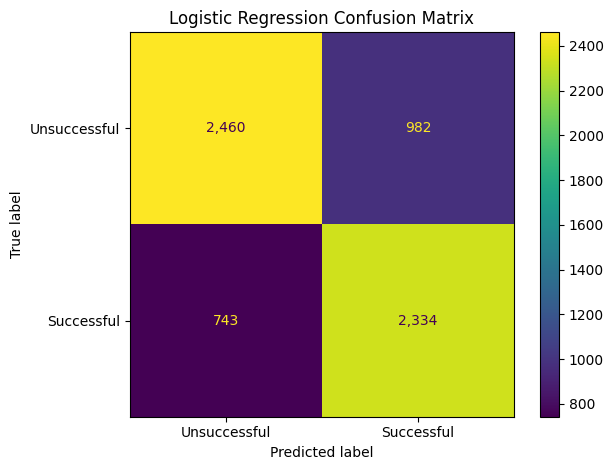

In [21]:
confusion = confusion_matrix(
    y_test,
    y_pred
)

display = ConfusionMatrixDisplay(
    confusion_matrix=confusion,
    display_labels=[
        "Unsuccessful",
        "Successful"
    ]
)

display.plot(
    values_format=","
)

plt.title(
    "Logistic Regression Confusion Matrix"
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR
    / "logistic_regression_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Classification Report

The classification report provides a detailed evaluation of the model's performance by measuring precision, recall, and F1 score for each outcome class.

The Day 30 Logistic Regression model demonstrated balanced predictive performance across both successful and unsuccessful students. Overall, the model achieved an **accuracy of 73.5%**, a **precision of 70.4%**, a **recall of 75.9%**, and an **F1 score of 73.0%**. These results indicate that the model effectively identifies student outcomes using only information available during the first 30 days of the course.

Although the classification metrics were lower than those of the full-course baseline model, this reduction was expected because the model intentionally excludes information collected later in the semester. Despite this limitation, the model maintains a strong balance between precision and recall, making it well suited as an early-warning model for identifying students who may benefit from timely academic support.

Overall, the classification report demonstrates that logistic regression provides a reliable and interpretable baseline for early prediction and serves as an appropriate benchmark for comparison with more complex machine learning algorithms.

## Confusion Matrix Interpretation

The confusion matrix summarizes the model's classification performance by comparing predicted outcomes with the actual student outcomes.

- **2,460 unsuccessful students** were correctly classified as unsuccessful.
- **2,334 successful students** were correctly classified as successful.
- **982 unsuccessful students** were incorrectly predicted to be successful.
- **743 successful students** were incorrectly predicted to be unsuccessful.

Although the Day 30 Logistic Regression model produced more classification errors than the full-course baseline model, this result was expected because predictions were intentionally limited to information available during the first 30 days of the course. Despite this constraint, the model correctly classified the majority of students and achieved balanced performance across both outcome classes.

The confusion matrix demonstrates that the model captures meaningful early indicators of student success while maintaining practical value for early intervention. Overall, these results support the use of logistic regression as a strong and interpretable baseline for early-warning student success prediction.

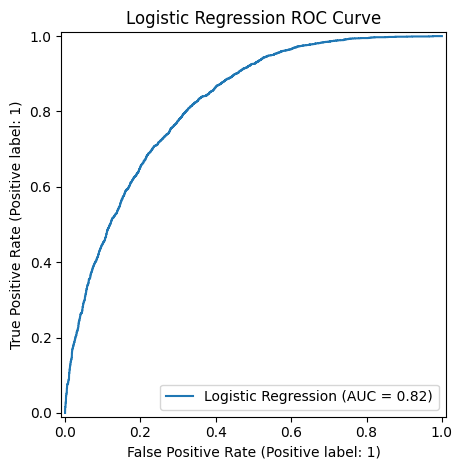

In [22]:
RocCurveDisplay.from_predictions(
    y_test,
    y_probability,
    name="Logistic Regression"
)

plt.title(
    "Logistic Regression ROC Curve"
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR
    / "logistic_regression_roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Receiver Operating Characteristic (ROC) Curve

The Receiver Operating Characteristic (ROC) curve illustrates the tradeoff between the true positive rate (sensitivity) and the false positive rate across all possible classification thresholds.

The Day 30 Logistic Regression model achieved a **ROC-AUC of 0.8193**, indicating good discrimination between successful and unsuccessful students using only information available during the first 30 days of the course. Although the ROC-AUC was lower than the full-course baseline model, this reduction was expected because later engagement and assessment information was intentionally excluded to simulate a realistic early-warning scenario.

Overall, the ROC analysis demonstrates that Logistic Regression provides a strong early-warning baseline for predicting student success. The model captures meaningful predictive signals early in the semester while preserving the practical value of identifying students who may benefit from timely academic interventions.

In [23]:
logistic_model = logistic_pipeline.named_steps["model"]

coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": logistic_model.coef_[0]
})

coefficients["Odds Ratio"] = np.exp(
    coefficients["Coefficient"]
)

coefficients["Absolute Coefficient"] = (
    coefficients["Coefficient"].abs()
)

coefficients = coefficients.sort_values(
    by="Absolute Coefficient",
    ascending=False
).reset_index(drop=True)

coefficients.head(20)

,Feature,Coefficient,Odds Ratio,Absolute Coefficient
0,assessments_completed,0.787830,2.198620,0.787830
1,log_assessments_completed,-0.602179,0.547617,0.602179
2,last_activity_day,0.542736,1.720709,0.542736
3,log_total_clicks,0.378670,1.460341,0.378670
4,studied_credits,-0.334608,0.715619,0.334608
5,score_range,0.328901,1.389441,0.328901
6,median_score,0.269644,1.309498,0.269644
7,first_submission_day,-0.263749,0.768166,0.263749
8,last_submission_day,-0.261923,0.769570,0.261923
9,activity_span_days,0.250737,1.284972,0.250737


## Coefficient Interpretation

The strongest logistic regression coefficients were associated primarily with early assessment performance, assessment completion, and patterns of virtual learning environment (VLE) engagement observed during the first 30 days of the course.

Because the predictors were standardized, each odds ratio represents the change in the odds of student success associated with a one-standard-deviation increase in that predictor while holding all other predictors constant.

Several predictors are correlated with one another, including assessment counts, assessment weights, score measures, and engagement variables. Consequently, individual coefficient estimates should be interpreted cautiously and should not be viewed as evidence of causal relationships.

Unlike the full-course baseline model, all engagement and assessment features in this notebook were calculated using only information available on or before **Day 30** of the course. Additionally, variables that would reveal future outcomes (such as withdrawal status and unregistration dates) were removed to prevent target leakage. As a result, this model represents a realistic early-warning prediction framework that could be deployed during the first month of a course to identify students who may benefit from timely academic interventions.

In [24]:
coefficients["Direction"] = np.where(
    coefficients["Coefficient"] > 0,
    "Higher predicted probability of success",
    "Lower predicted probability of success"
)

coefficients.head(20)

,Feature,Coefficient,Odds Ratio,Absolute Coefficient,Direction
0,assessments_completed,0.787830,2.198620,0.787830,Higher predicted probability of success
1,log_assessments_completed,-0.602179,0.547617,0.602179,Lower predicted probability of success
2,last_activity_day,0.542736,1.720709,0.542736,Higher predicted probability of success
3,log_total_clicks,0.378670,1.460341,0.378670,Higher predicted probability of success
4,studied_credits,-0.334608,0.715619,0.334608,Lower predicted probability of success
5,score_range,0.328901,1.389441,0.328901,Higher predicted probability of success
6,median_score,0.269644,1.309498,0.269644,Higher predicted probability of success
7,first_submission_day,-0.263749,0.768166,0.263749,Lower predicted probability of success
8,last_submission_day,-0.261923,0.769570,0.261923,Lower predicted probability of success
9,activity_span_days,0.250737,1.284972,0.250737,Higher predicted probability of success


In [25]:
COEFFICIENTS_PATH = (
    PROCESSED_DATA_DIR /
    "logistic_regression_early_warning_coefficients.csv"
)

coefficients.to_csv(
    COEFFICIENTS_PATH,
    index=False
)

print("Saved:")
print(COEFFICIENTS_PATH)

Saved:
/content/drive/MyDrive/SEAID_Framework/data/processed/logistic_regression_early_warning_coefficients.csv


In [26]:
MODEL_PATH = (
    MODELS_DIR /
    "logistic_regression_full_course_baseline.joblib"
)

joblib.dump(
    logistic_pipeline,
    MODEL_PATH
)

print("Saved:")
print(MODEL_PATH)

Saved:
/content/drive/MyDrive/SEAID_Framework/models/logistic_regression_full_course_baseline.joblib


In [27]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_probability)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

Accuracy : 0.7354
Precision: 0.7039
Recall   : 0.7585
F1 Score : 0.7302
ROC-AUC  : 0.8193


In [28]:
metrics_df = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],
    "Value": [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ]
})

METRICS_PATH = (
    PROCESSED_DATA_DIR /
    "logistic_regression_early_warning_test_metrics.csv"
)

metrics_df.to_csv(
    METRICS_PATH,
    index=False
)

metrics_df

,Metric,Value
0,Accuracy,0.735389
1,Precision,0.703860
2,Recall,0.758531
3,F1 Score,0.730174
4,ROC-AUC,0.819252


In [29]:
print("Model exists:")
print(MODEL_PATH.exists())

print()

print("Coefficient file exists:")
print(COEFFICIENTS_PATH.exists())

print()

print("Metrics file exists:")
print(METRICS_PATH.exists())

Model exists:
True

Coefficient file exists:
True

Metrics file exists:
True


# Notebook Summary

This notebook developed and evaluated a logistic regression model using the Day 30 early-warning dataset. Unlike the full-course baseline model, this analysis was intentionally restricted to information available during the first 30 days of the course, including student engagement, assessment performance, registration characteristics, and demographic variables.

## Model Performance

| Metric | Value |
|:--------|------:|
| Accuracy | **73.5%** |
| Precision | **70.4%** |
| Recall | **75.9%** |
| F1 Score | **73.0%** |
| ROC-AUC | **0.819** |

## Interpretation

The Day 30 logistic regression model achieved an accuracy of **73.5%** and a **ROC-AUC of 0.819**, demonstrating that meaningful predictions can be made using only information available during the first month of a course. Although performance was lower than the full-course baseline model, this reduction was expected because later engagement and assessment information was intentionally excluded to simulate a realistic early-warning scenario.

The model's **75.9% recall** indicates that it correctly identified a substantial proportion of students who ultimately completed the course successfully. Overall, these findings suggest that early engagement, assessment performance, registration characteristics, and demographic information contain valuable predictive signals that could support timely student interventions before academic outcomes are finalized.

## Next Steps

The next notebook will evaluate a Decision Tree classifier using the same Day 30 dataset. Comparing the logistic regression and decision tree models will help determine whether a nonlinear modeling approach improves predictive performance while maintaining the practical constraints of an early-warning system.